In [1]:
import os
import logging
import time
from functools import partial
import numpy as np
import h5py
import jax
import jax.numpy as jnp
from flax import nnx
import optax
import matplotlib.pyplot as plt
from heavyhex_qft.triangular_z2 import TriangularZ2Lattice
from skqd_z2lgt.parameters import Parameters, DMRGParameters, LGTParameters
from skqd_z2lgt.recovery.crbm import ConditionalRBM
from skqd_z2lgt.recovery.loss import cd_meanloss, make_l2_loss_fn
from skqd_z2lgt.recovery.callback import SuccessRateCallback
from skqd_z2lgt.recovery.train import train_crbm
from skqd_z2lgt.tasks.open_output import open_output
from skqd_z2lgt.tasks.sample_quantum import sample_quantum, get_trotter_circuits, load_raw
from skqd_z2lgt.tasks.preprocess import load_reco
from skqd_z2lgt.utils import read_bits
# from skqd_z2lgt.tasks.train_generator import train_generator, load_model

visible_devices = '9'
os.environ['CUDA_VISIBLE_DEVICES'] = visible_devices
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '.99'
jax.config.update('jax_enable_x64', True)
logging.basicConfig(level=logging.INFO)
logging.getLogger('skqd_z2lgt').setLevel(logging.DEBUG)

LOG = logging.getLogger()

In [2]:
pkgpath = '/data/iiyama/2dz2/experiment_800k_aachen'
parameters = open_output(pkgpath)
cparams = parameters.crbm
cparams.l2w_biases = 1.
cparams.train_batch_size = 64

nsteps = len(parameters.circuit.sampled_steps)
raw_data = load_raw(parameters, etype='ref')
reco_data = load_reco(parameters, etype='ref')

INFO:skqd_z2lgt.tasks.open_output:Validating configurations in existing file /data/iiyama/2dz2/experiment_800k_aachen


In [ ]:
vtx_data, plaq_data = reco_data[0][1]

In [4]:
link_data = read_bits(raw_data[0][1].array, num_bits=raw_data[0][1].num_bits, align='right')

In [5]:
# mean_activation = np.mean(train_v, axis=0)
# mean_activation = np.where(np.isclose(mean_activation, 0.), 1.e-6, mean_activation)
# bias_init = np.log(mean_activation / (1. - mean_activation))

rngs = nnx.Rngs(params=1234, sample=5678)
model = ConditionalRBM(vtx_data.shape[-1], plaq_data.shape[-1], cparams.num_h, rngs=rngs)
# model.bias_v.value = bias_init
bias_h_val = np.log(cparams.init_h_sparsity / (1. - cparams.init_h_sparsity))
# model.bias_h.value = jnp.full(cparams.num_h, bias_h_val)

loss_fn_train = make_l2_loss_fn(partial(cd_meanloss, impl='sum', unroll=20),
                                cparams.l2w_weights, cparams.l2w_biases)
loss_fn_test = make_l2_loss_fn(partial(cd_meanloss, impl='tensordot', unroll=50),
                               cparams.l2w_weights, cparams.l2w_biases)

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


In [6]:
model.sample(vtx_data[:5], 100).shape

(100, 5, 31)

In [7]:
def free_energy(model, u_batch, v_batch, _):
    return jnp.mean(model.free_energy(u_batch, v_batch))

def success_100(model, u_batch, v_batch, _):
    samples = model.sample(u_batch, 100)  # size comes at axis 0
    test = jnp.all(jnp.equal(v_batch[None, ...], samples), axis=-1)
    return jnp.mean(jnp.any(test, axis=0).astype(int))

metrics_train = {'free_energy': (nnx.metrics.Average, free_energy)}
metrics_test = {'success_100': (nnx.metrics.Average, success_100)}

best_model, records_train, records_test = train_crbm(model, (vtx_data, plaq_data), num_epochs=10,
                                 loss_fn_train=loss_fn_train, loss_fn_test=loss_fn_test,
                                 lr=cparams.learning_rate,
                                 metrics_train=metrics_train, metrics_test=metrics_test)


INFO:skqd_z2lgt.recovery.train:Starting epoch 0/10
DEBUG:skqd_z2lgt.recovery.train:Processed one epoch in 16.82 seconds
DEBUG:skqd_z2lgt.recovery.train:Got best model so far with epoch mean loss 5.362e+00
DEBUG:skqd_z2lgt.recovery.train:Applying model to test data
DEBUG:skqd_z2lgt.recovery.train:Processed test data in 6.28 seconds
INFO:skqd_z2lgt.recovery.train:Starting epoch 1/10
DEBUG:skqd_z2lgt.recovery.train:Processed one epoch in 12.51 seconds
DEBUG:skqd_z2lgt.recovery.train:Got best model so far with epoch mean loss 5.039e-01
DEBUG:skqd_z2lgt.recovery.train:Applying model to test data
DEBUG:skqd_z2lgt.recovery.train:Processed test data in 0.60 seconds
INFO:skqd_z2lgt.recovery.train:Starting epoch 2/10
DEBUG:skqd_z2lgt.recovery.train:Processed one epoch in 12.39 seconds
DEBUG:skqd_z2lgt.recovery.train:Got best model so far with epoch mean loss 2.534e-01
DEBUG:skqd_z2lgt.recovery.train:Applying model to test data
DEBUG:skqd_z2lgt.recovery.train:Processed test data in 0.60 seconds
I

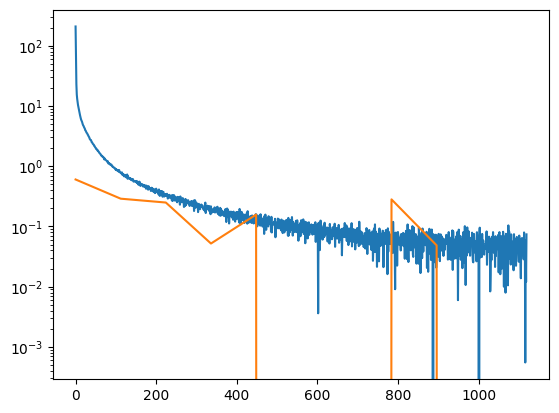

In [10]:
plt.plot(np.arange(1120), records_train['loss'].reshape(-1))
plt.plot(np.arange(0, 1120, 112), records_test['loss'])
plt.yscale('log')

In [11]:
size_full = vtx_data.shape[0]
test_batch_size = 1000
size_train = np.ceil(size_full * 0.9).astype(int)
size_test = size_full - size_train
num_test_batches = size_test // test_batch_size
size_test = num_test_batches * test_batch_size

In [12]:
vtx_test = vtx_data[-size_test:]
plaq_test = plaq_data[-size_test:]
link_test = link_data[-size_test:]

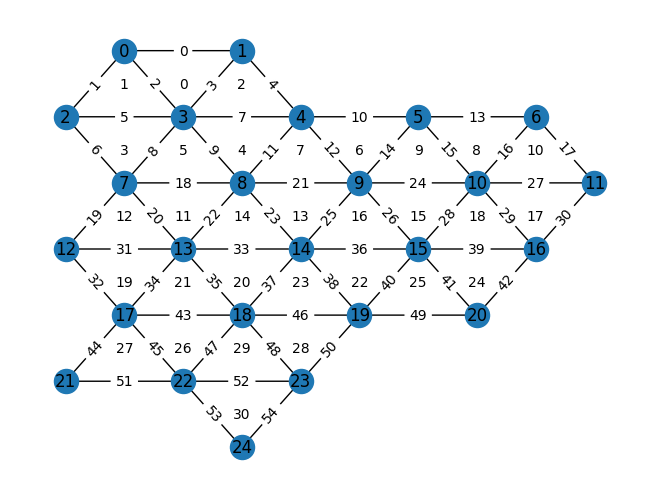

In [13]:
lattice = TriangularZ2Lattice(parameters.lgt.lattice)
lattice.draw_graph();

In [46]:
vuniq, vcounts = np.unique(vtx_test, axis=0, return_counts=True)

In [49]:
sorter = np.argsort(vcounts)[::-1]

In [50]:
sorter

array([    0,  1427,  4952, ..., 12018, 12017, 12016], shape=(12063,))

In [59]:
np.nonzero(vuniq[4952][::-1])

(array([15, 20]),)

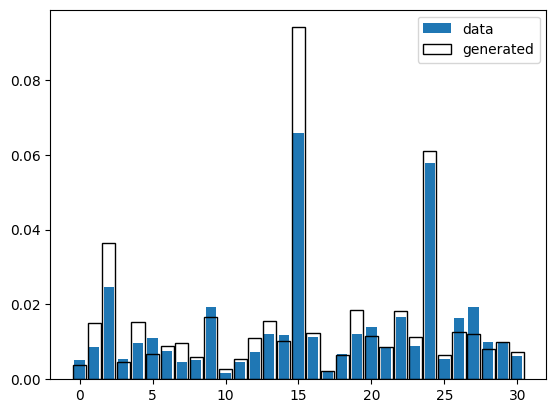

In [70]:
pidx = sorter[0]
matches = np.nonzero(np.all(vtx_test == vuniq[pidx], axis=1))[0]
plt.bar(np.arange(31), np.mean(plaq_test[matches], axis=0)[::-1], width=0.7, label='data')
plt.bar(np.arange(31), np.mean(best_model.sample(vuniq[pidx], matches.shape[0]), axis=0)[::-1], width=0.9, fill=False, label='generated')
plt.legend();

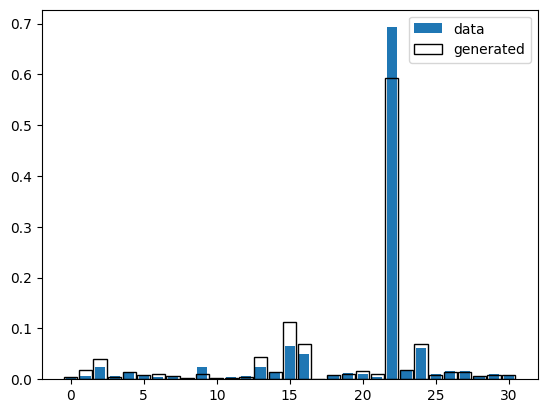

In [71]:
pidx = sorter[1]
matches = np.nonzero(np.all(vtx_test == vuniq[pidx], axis=1))[0]
plt.bar(np.arange(31), np.mean(plaq_test[matches], axis=0)[::-1], width=0.7, label='data')
plt.bar(np.arange(31), np.mean(best_model.sample(vuniq[pidx], matches.shape[0]), axis=0)[::-1], width=0.9, fill=False, label='generated')
plt.legend();

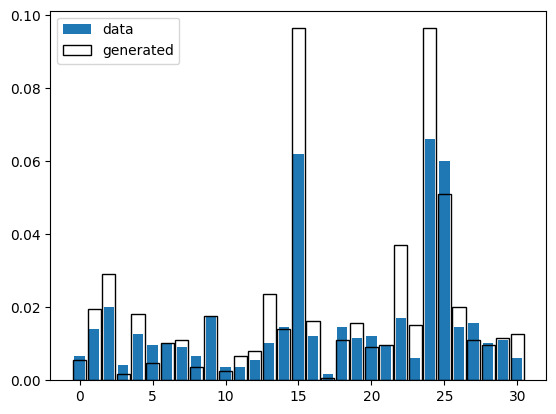

In [72]:
pidx = sorter[2]
matches = np.nonzero(np.all(vtx_test == vuniq[pidx], axis=1))[0]
plt.bar(np.arange(31), np.mean(plaq_test[matches], axis=0)[::-1], width=0.7, label='data')
plt.bar(np.arange(31), np.mean(best_model.sample(vuniq[pidx], matches.shape[0]), axis=0)[::-1], width=0.9, fill=False, label='generated')
plt.legend();

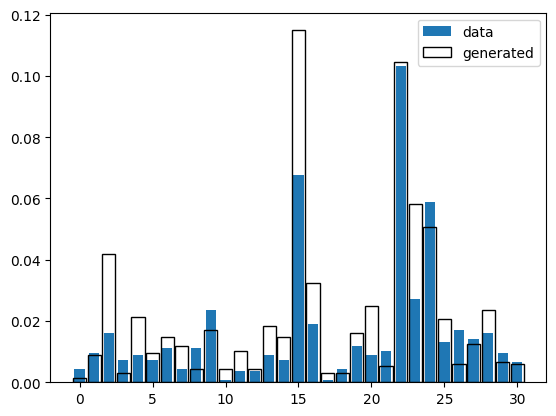

In [73]:
pidx = sorter[3]
matches = np.nonzero(np.all(vtx_test == vuniq[pidx], axis=1))[0]
plt.bar(np.arange(31), np.mean(plaq_test[matches], axis=0)[::-1], width=0.7, label='data')
plt.bar(np.arange(31), np.mean(best_model.sample(vuniq[pidx], matches.shape[0]), axis=0)[::-1], width=0.9, fill=False, label='generated')
plt.legend();

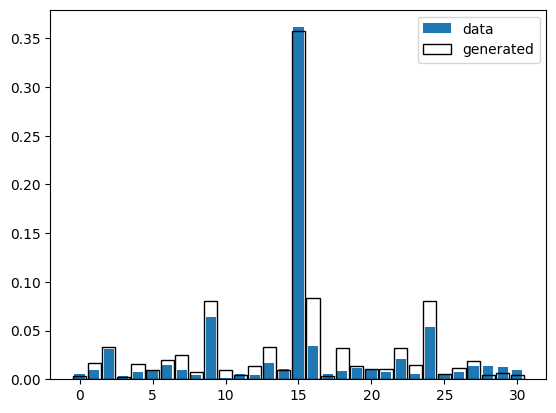

In [74]:
pidx = sorter[4]
matches = np.nonzero(np.all(vtx_test == vuniq[pidx], axis=1))[0]
plt.bar(np.arange(31), np.mean(plaq_test[matches], axis=0)[::-1], width=0.7, label='data')
plt.bar(np.arange(31), np.mean(best_model.sample(vuniq[pidx], matches.shape[0]), axis=0)[::-1], width=0.9, fill=False, label='generated')
plt.legend();

In [80]:
np.nonzero(np.count_nonzero(vuniq[sorter[:100]], axis=1) == 4)[0]

array([54, 55, 58, 59, 62, 64, 66, 67, 68, 69, 70, 75, 76, 77, 79, 80, 81,
       82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 95, 97, 98, 99])

In [81]:
vcounts[sorter[54]]

np.int64(182)

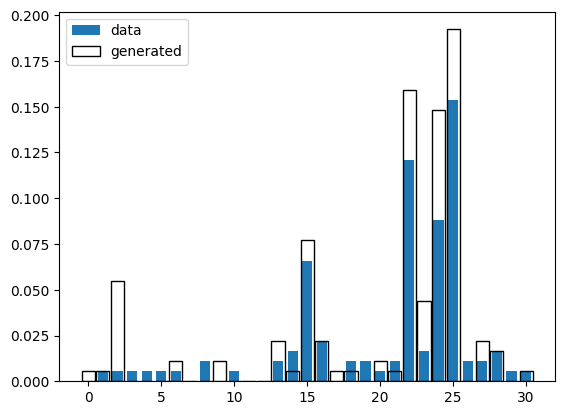

In [82]:
pidx = sorter[54]
matches = np.nonzero(np.all(vtx_test == vuniq[pidx], axis=1))[0]
plt.bar(np.arange(31), np.mean(plaq_test[matches], axis=0)[::-1], width=0.7, label='data')
plt.bar(np.arange(31), np.mean(best_model.sample(vuniq[pidx], matches.shape[0]), axis=0)[::-1], width=0.9, fill=False, label='generated')
plt.legend();

In [83]:
for pidx in sorter[:5]:
    print(np.nonzero(vuniq[pidx][::-1])[0])

[]
[14 15]
[15 20]
[14 19]
[ 9 10]


In [84]:
print(np.nonzero(vuniq[sorter[54]][::-1])[0])

[14 15 19 20]
